<h1>Chapter 5 | Data Exercise #4 | <code>wms-managemenet-survey</code> | Generalizing from Data</h1>


<h2>Introduction:</h2>
<p>In this notebook, you will find my notes and code for Chapter 5's <b>exercise 4</b> of the book <a href="https://gabors-data-analysis.com/">Data Analysis for Business, Economics, and Policy</a>, by Gábor Békés and Gábor Kézdi. The question was: 
<p>4. Use the <code>wms-management-survey</code> dataset and pick two countries.
<p>Assignments:</p>
<ul>
    <li>Estimate the average management quality score in each.</li>
    <li>Estimate their standard errors by bootstrap and using the SE formula. </li>
    <li>Create 95% confidence intervals.</li>
    <li>Compare the average values and the confidence intervals across the two countries, and explain why you have a narrower CI for one city than the other.</li>
    <li>Discuss the external validity of your results for the quality of management in your country of origin in the current year.</li>



</ul>
<h2>1. Load the data</h2>

In [2]:
import os
import pandas as pd
import warnings
from datetime import datetime
from plotnine import *
import sys
import numpy as np
from scipy.stats import norm, sem
from numpy.random import choice
warnings.filterwarnings("ignore")

In [3]:
# Increase number of returned rows in pandas
pd.set_option("display.max_rows", 500)

In [4]:
# Current script folder
dirname = os.getcwd()

# Get location folders
data_in = f"{dirname}/da_data_repo/wms-management-survey/clean/"
data_out = f"{dirname}/da_data_exercises/ch05-generalizing_from_data/04-wms_management_generalize/data/clean/"
output = f"{dirname}/da_data_exercises/ch05-generalizing_from_data/04-wms_management_generalize/data/output/"
func = f"{dirname}/da_case_studies/ch00-tech_prep/"
sys.path.append(func)
paths = [data_in, data_out, output]

for path in paths:
    if not os.path.exists(path):
        os.makedirs(path)

In [5]:
# Import the prewritten helper functions 
from py_helper_functions import *

In [6]:
wms_data = pd.read_csv(f"{data_in}/wms_da_textbook.csv")

In [7]:
wms_data.head()

,firmid,wave,cty,country,sic,management,operations,monitor,target,people,...,aa_196,aa_197,aa_198,aa_199,aa_200,aa_201,aa_202,aa_203,aa_204,aa_205
0,1,2004,us,United States,38.0,3.500000,3.0,3.6,3.6,3.500000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2006,us,United States,38.0,3.166667,5.0,3.8,2.6,2.500000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,2010,us,United States,38.0,3.000000,2.0,2.8,3.6,3.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2,2004,us,United States,28.0,4.666667,4.5,4.8,4.4,4.833333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2,2004,us,United States,28.0,4.444445,4.5,4.6,4.4,4.333333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 2. Pick two countries

Let's take a look at unique Country values.

In [8]:
wms_data["country"].unique()

array(['United States', 'India', 'New Zealand', 'Australia', 'Argentina',
       'Brazil', 'Canada', 'Chile', 'China', 'Germany', 'Spain', 'France',
       'Northern Ireland', 'Great Britain', 'Greece',
       'Republic of Ireland', 'Italy', 'Japan', 'Mexico', 'Poland',
       'Portugal', 'Sweden', 'Singapore', 'Turkey'], dtype=object)

## 2.1 Sample Selection
Let's do something different. Differently than previous exercises, let's try to pick countries that share similar economic features. We could use `France` and `Germany`.

In [9]:
wms_countries = wms_data.loc[
    lambda x: (wms_data["country"].isin(["France", "Germany"]))
]

In [10]:
wms_countries["country"].value_counts()

country
France     764
Germany    724
Name: count, dtype: int64

# 3. Estimate the average management quality score in each.

In [11]:
wms_countries.describe() 

,firmid,wave,sic,management,operations,monitor,target,people,lean1,lean2,...,aa_196,aa_197,aa_198,aa_199,aa_200,aa_201,aa_202,aa_203,aa_204,aa_205
count,1488.000000,1488.000000,1488.000000,1488.000000,1488.000000,1488.000000,1488.000000,1488.000000,1488.000000,1453.000000,...,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0,1488.0
mean,4357.362231,2007.489247,30.763441,3.118022,3.112399,3.496237,3.072312,2.839225,3.034946,3.212319,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,360.009715,3.322179,5.472849,0.611819,1.000929,0.745281,0.726464,0.639164,1.092458,1.076211,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,3802.000000,2004.000000,20.000000,1.111111,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,4025.750000,2006.000000,27.000000,2.722222,2.500000,3.000000,2.600000,2.400000,2.000000,3.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,4453.000000,2006.000000,33.000000,3.111111,3.000000,3.600000,3.200000,2.833333,3.000000,3.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,4690.250000,2010.000000,35.000000,3.555556,4.000000,4.000000,3.600000,3.166667,4.000000,4.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,4923.000000,2014.000000,39.000000,4.777778,5.000000,5.000000,5.000000,4.666667,5.000000,5.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
wms_countries.groupby(by="country")["management"].mean()

country
France     3.018879
Germany    3.222643
Name: management, dtype: float64

We can see that the average management score for **France** is **3.01** and for **Germany**, **3.22**.

# 4. Estimate their standard errors by bootstrap and using the SE formula
## 4.1 France
### 4.1.1 Bootstrap


In [13]:
wms_france = wms_countries[wms_countries["country"] == "France"]
wms_france.describe()

,firmid,wave,sic,management,operations,monitor,target,people,lean1,lean2,...,aa_196,aa_197,aa_198,aa_199,aa_200,aa_201,aa_202,aa_203,aa_204,aa_205
count,764.000000,764.000000,764.000000,764.000000,764.000000,764.000000,764.000000,764.000000,764.000000,731.000000,...,764.0,764.0,764.0,764.0,764.0,764.0,764.0,764.0,764.0,764.0
mean,4683.205497,2007.924084,30.049738,3.018879,3.028796,3.441688,2.961322,2.706021,3.026178,3.065663,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,140.099088,3.487404,5.668439,0.628855,1.055080,0.766504,0.753845,0.632786,1.126051,1.123137,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,4440.000000,2004.000000,20.000000,1.111111,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,4562.750000,2006.000000,26.000000,2.647059,2.500000,3.000000,2.400000,2.333333,2.000000,2.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,4683.500000,2006.000000,31.000000,3.000000,3.000000,3.400000,3.000000,2.666667,3.000000,3.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,4806.000000,2010.000000,35.000000,3.388889,4.000000,4.000000,3.400000,3.000000,4.000000,4.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,4923.000000,2014.000000,39.000000,4.777778,5.000000,5.000000,5.000000,4.666667,5.000000,5.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Visualize the distribution of our population.

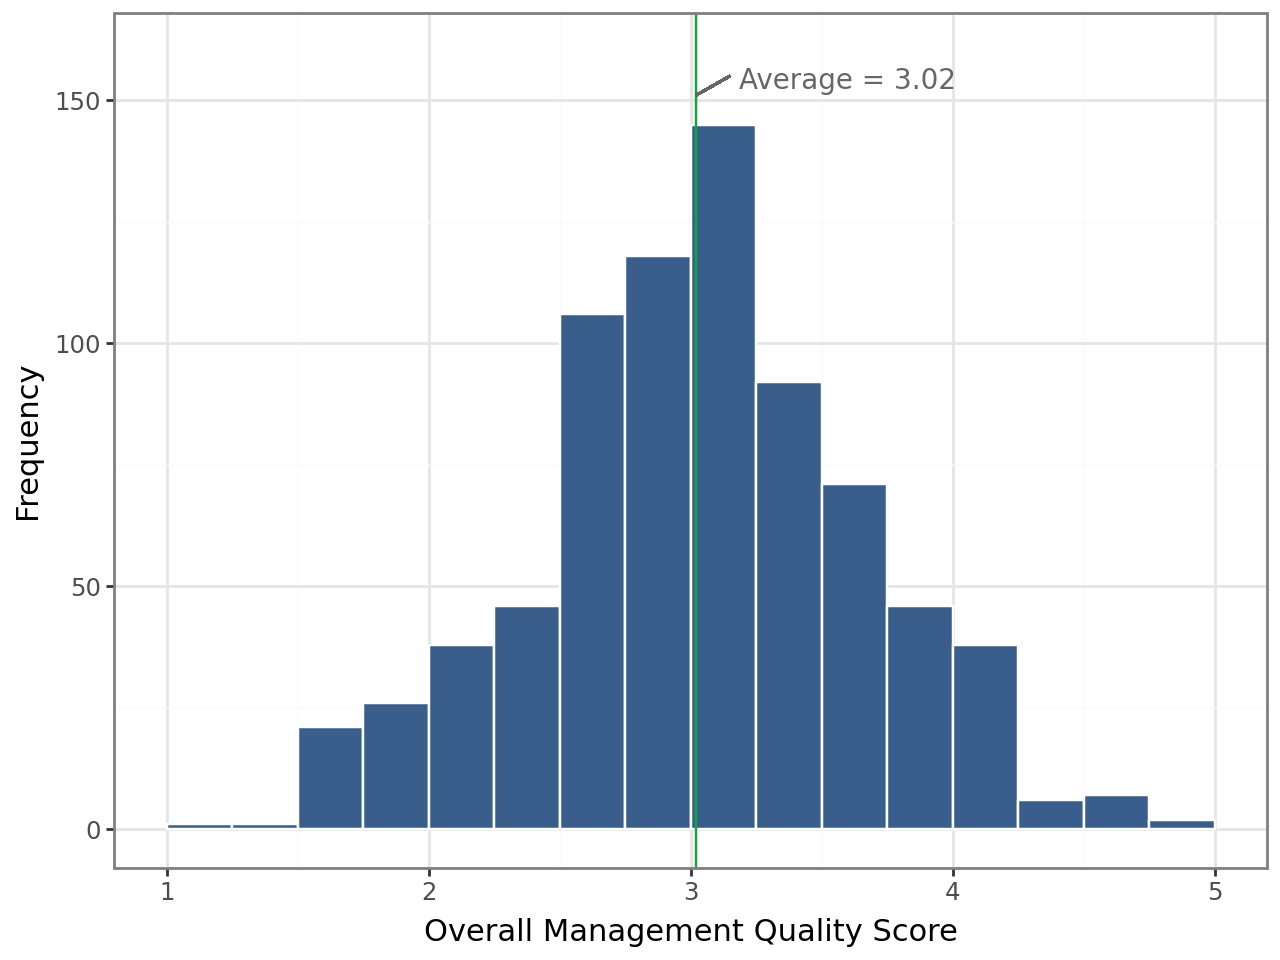

In [14]:
ggplot(wms_france, aes("management")) + geom_histogram(
    binwidth=0.25,color="white",fill=color[0], closed="left", boundary=0
) + geom_vline(xintercept=3.0188, color=color[1]) + labs(
    x="Overall Management Quality Score", y="Frequency"
) + coord_cartesian(xlim=[1,5], ylim=[0,160]
) + geom_segment(aes(x=3.15, y=155, xend=3.01887, yend=151), lineend="projecting", color="#666666"
) + annotate(
        "text", x=3.6, y=154, label = f"Average = {wms_france["management"].mean():.2f}", size=10, color="#666666"
) + theme_bw()

As we can see, a somewhat normal distribution. Let's create samples based on our total population of 764 observations.

In [15]:
def create_bootstrap_samples(vector, n_samples=1000):
    """
    Performs Standard Boostrap for the Mean.
    """

    # Use the size of the original vector
    n_obs = len(vector)

    # Pre-allocate space (0 to n_samples-1)
    samples_mean = np.zeros(n_samples)

    for i in range(n_samples):
        single_sample = np.random.choice(vector, size=n_obs, replace=True)

        samples_mean[i] = np.mean(single_sample)

    return samples_mean

In [16]:
france_means = create_bootstrap_samples(wms_france["management"])

In [17]:
france_means

array([2.99293533, 3.02282662, 3.05596873, 3.00689632, 3.00163501,
       2.9794266 , 3.028845  , 3.00982809, 3.06868979, 3.0358468 ,
       2.99809425, 2.97974305, 3.03575698, 2.99126961, 2.96399668,
       3.01333939, 3.01679413, 3.0361299 , 3.02988404, 3.01125248,
       3.01654352, 3.04105614, 3.03383743, 2.97401783, 3.01304909,
       3.03637713, 2.98081808, 3.05023134, 2.98434623, 3.02581011,
       3.02125527, 3.01172075, 3.04322627, 3.03599424, 2.99707272,
       3.05407373, 3.03994575, 2.98617741, 2.96114417, 2.99449178,
       2.99207719, 2.99384222, 3.04394182, 3.02815444, 3.03399085,
       3.03207463, 2.98993569, 3.03717414, 3.03250176, 2.97159772,
       2.99058762, 3.03092342, 3.0007497 , 3.04195305, 2.99678068,
       2.98100177, 2.99969683, 3.05080698, 3.06441009, 2.97414167,
       3.0347023 , 3.00688809, 3.00623461, 3.04105218, 2.99246815,
       3.02809203, 3.02191632, 3.05125615, 2.9808954 , 3.00678542,
       3.01593046, 3.04790369, 3.00364264, 3.03267364, 3.03454

Let's plot a histogram of our boostrap experiment and see what it looks like.

In [18]:
wms_france_bootstrap = pd.DataFrame({"management": france_means})

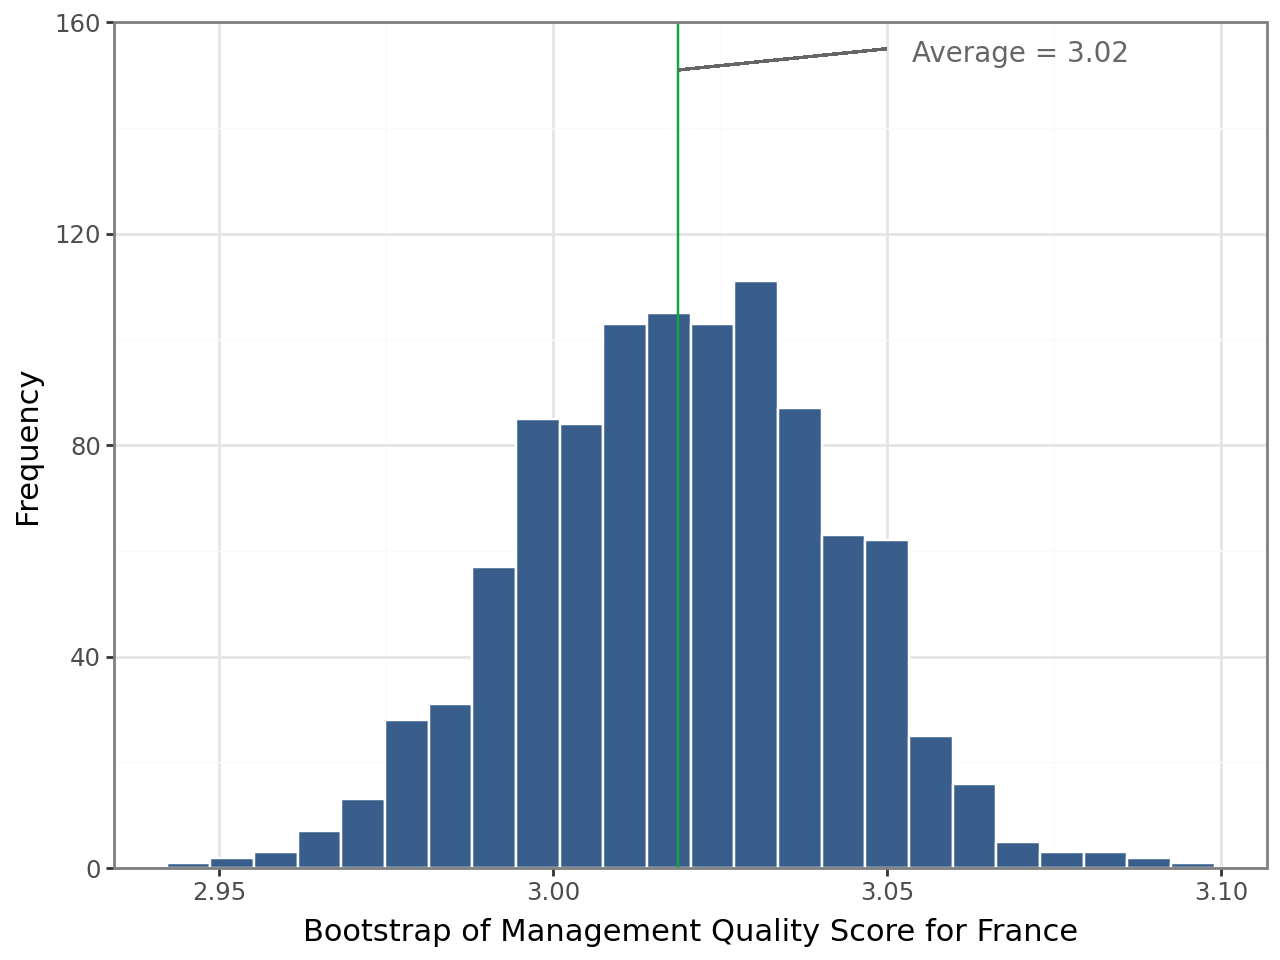

In [19]:
ggplot(wms_france_bootstrap, aes("management")) + geom_histogram(
    color="white",fill=color[0], closed="left", boundary=0
) + geom_vline(xintercept=3.0188, color=color[1]) + labs(
    x="Bootstrap of Management Quality Score for France", y="Frequency"
) + scale_y_continuous(expand=[0,0]
) + coord_cartesian(ylim=[0, 160]

) + geom_segment(aes(x=3.05, y=155, xend=3.01887, yend=151), lineend="projecting", color="#666666"
) + annotate(
        "text", x=3.07, y=154, label = f"Average = {wms_france_bootstrap["management"].mean():.2f}", size=10, color="#666666"
) + theme_bw()

In [20]:
wms_france_bootstrap.describe()

,management
count,1000.000000
mean,3.019215
std,0.022824
min,2.947253
25%,3.003110
50%,3.019578
75%,3.034737
max,3.097631


This is very informative.
- Our bootstrap sample has, as expected, a normal distribution.
- The mean is the same of our population (3.018).
- We can already see the standard error (which is our std). It is `0.023`.

Let's calculate these values with NumPy and the SE formula.


In [21]:
france_SE = np.std(france_means, ddof=1)
france_SE

np.float64(0.0228244255675406)

Interesting. Our original standard deviation was higher - `0.62`. Our Standard Error is `0.023`.
### 4.1.2 Formula

In [22]:
france_SE_formula = np.std(wms_france["management"], ddof=1) / (np.sqrt(len(wms_france["management"])))
france_SE_formula

np.float64(0.022751162688423397)

-----
# 4.2 Germany
## 4.2.1 Boostrap

In [24]:
wms_germany = wms_countries[wms_countries["country"] == "Germany"]
wms_germany["management"].describe()

count    724.000000
mean       3.222643
std        0.575489
min        1.388889
25%        2.833333
50%        3.222222
75%        3.611111
max        4.722222
Name: management, dtype: float64

We can already see that the average `management` is `3.22` and the standard deviation is slighlty lower - `0.57`.

Let's visualize the distribution of `management`.

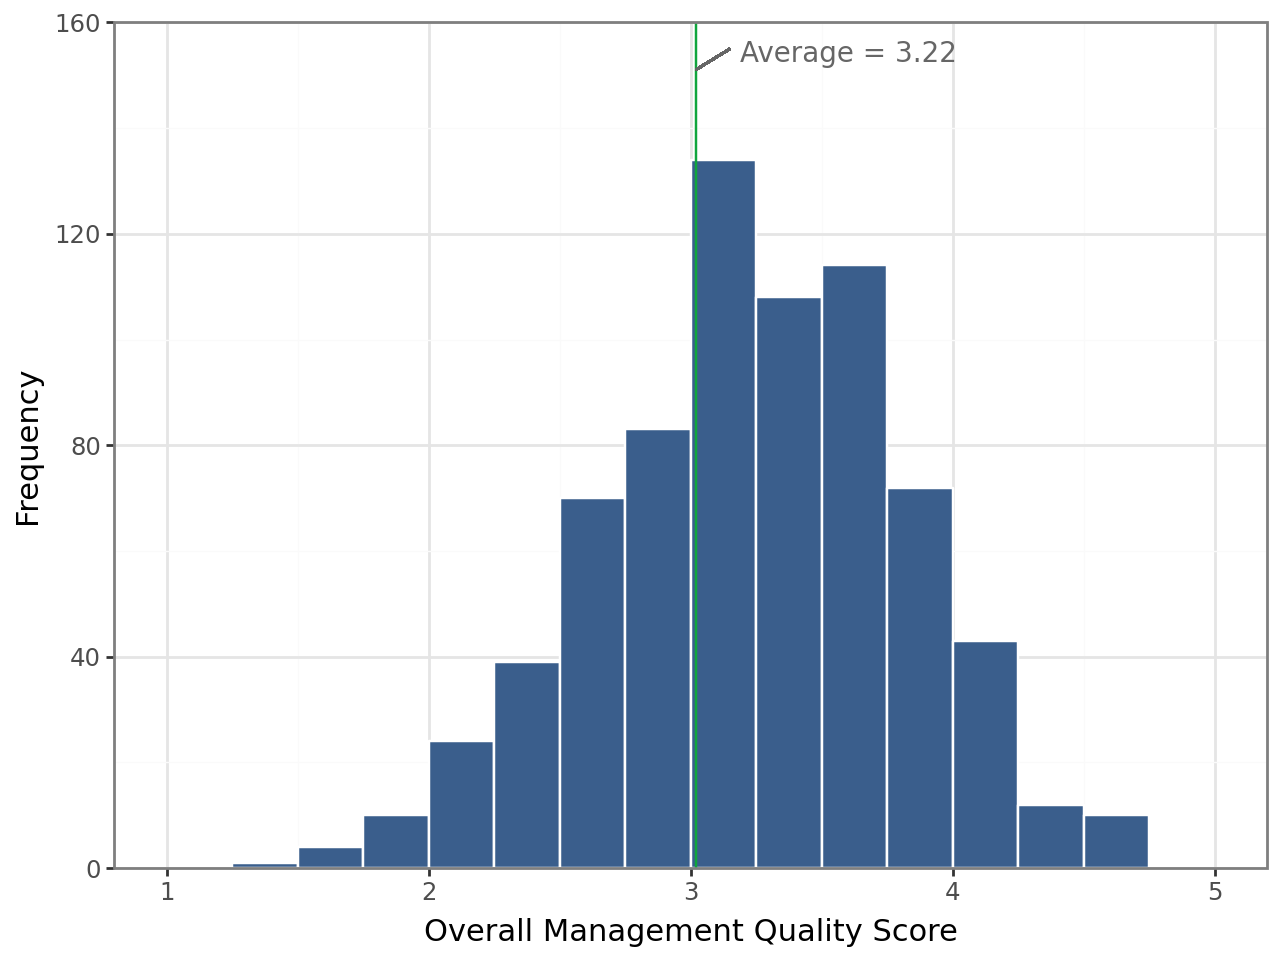

In [27]:
ggplot(wms_germany, aes("management")) + geom_histogram(
    binwidth=0.25,color="white",fill=color[0], closed="left", boundary=0
) + geom_vline(xintercept=3.0188, color=color[1]) + labs(
    x="Overall Management Quality Score", y="Frequency"
) + scale_y_continuous(expand=[0,0]
) + coord_cartesian(xlim=[1,5], ylim=[0,160]
) + geom_segment(aes(x=3.15, y=155, xend=3.01887, yend=151), lineend="projecting", color="#666666"
) + annotate(
        "text", x=3.6, y=154, label = f"Average = {wms_germany["management"].mean():.2f}", size=10, color="#666666"
) + theme_bw()

Create our bootstrap samples based on our 724 observations.

In [28]:
germany_means = create_bootstrap_samples(wms_germany["management"])

In [29]:
germany_bootstrap = pd.DataFrame({"management": germany_means})

In [31]:
germany_bootstrap.describe()

,management
count,1000.000000
mean,3.222798
std,0.020384
min,3.167393
25%,3.208776
50%,3.222948
75%,3.237012
max,3.278950


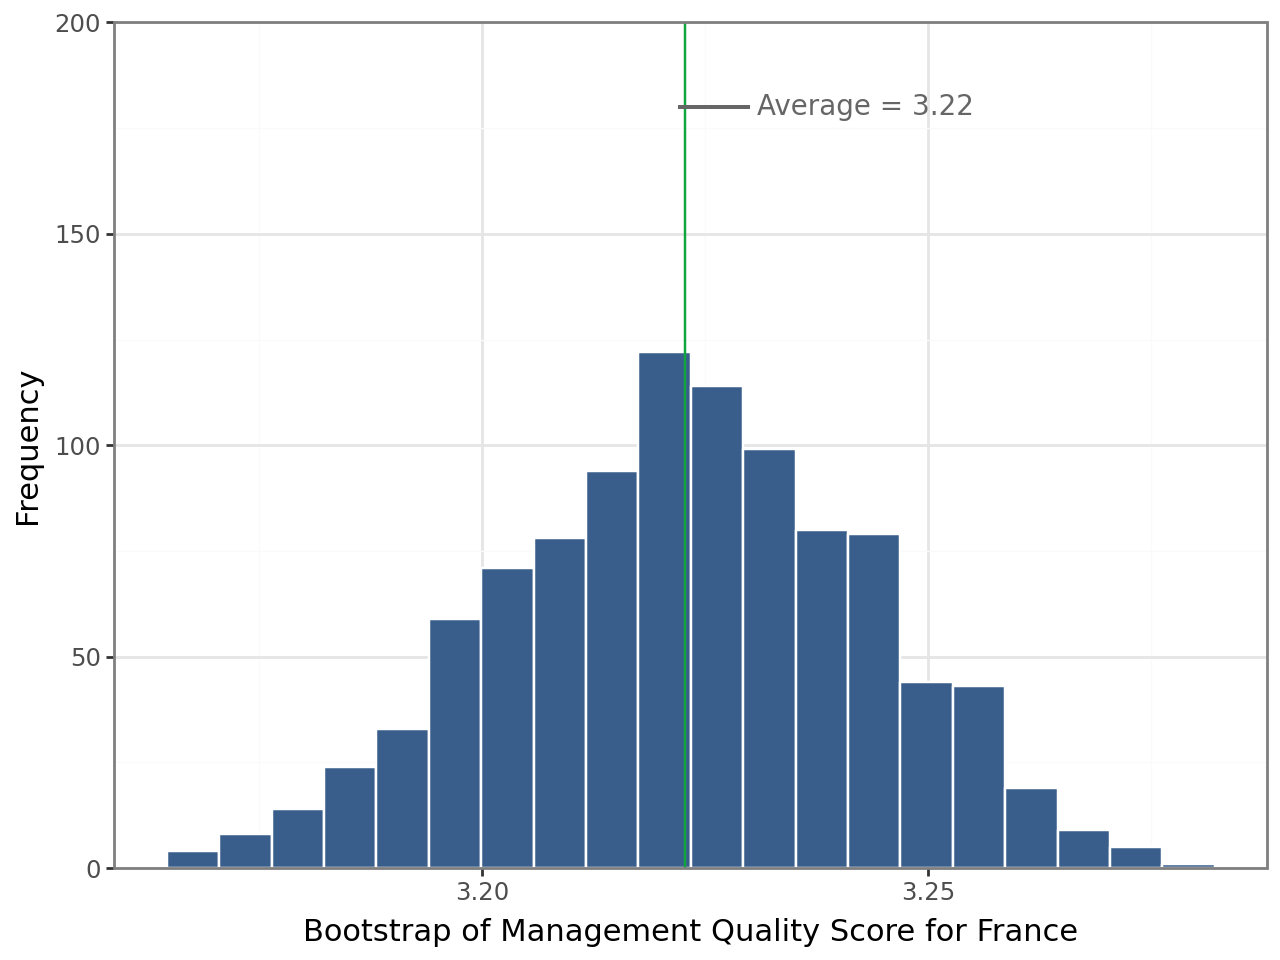

In [52]:
ggplot(germany_bootstrap, aes("management")) + geom_histogram(
    color="white",fill=color[0], closed="left", boundary=0
) + geom_vline(xintercept=germany_bootstrap["management"].mean(), color=color[1]) + labs(
    x="Bootstrap of Management Quality Score for France", y="Frequency"
) + scale_y_continuous(expand=[0,0]
) + coord_cartesian(ylim=[0, 200]

) + geom_segment(aes(x=3.222, y=180, xend=3.23, yend=180), lineend="projecting", color="#666666"
) + annotate(
        "text", x=3.243, y=180, label = f"Average = {germany_bootstrap["management"].mean():.2f}", size=10, color="#666666"
) + theme_bw()

This is very informative.
- Our bootstrap sample has, as expected, a normal distribution.
- The mean is the same of our population (3.22).
- We can already see the standard error (which is our std). It is `0.020`.

Let's calculate these values with NumPy and the SE formula.


In [53]:
germany_SE = np.std(germany_means, ddof=1)
germany_SE

np.float64(0.02038395078841968)

As we can see, very close results!

### 4.2.2 Formula

In [57]:
germany_SE_formula = np.std(wms_germany["management"], ddof=1) / (np.sqrt(len(wms_germany["management"])))
germany_SE_formula

np.float64(0.021387870394870015)

# 5. Create 95% confidence intervals.
## 5.1 France

In [62]:
Z = norm.ppf(0.975)
CI_lower_fra = (np.mean(france_means) - Z * france_SE)
CI_upper_fra = (np.mean(france_means) + Z * france_SE)

print(f"The 95% CI for France is [{CI_lower_fra:.2f}, {CI_upper_fra:.2f}]")
print(f"This represents a range of {(CI_upper_fra - CI_lower_fra):.2f} points")

The 95% CI for France is [2.97, 3.06]
This represents a range of 0.09 points


## 5.2 Germany

In [63]:
CI_lower_ger = (np.mean(germany_means) - Z * germany_SE)
CI_upper_ger = (np.mean(germany_means) + Z * germany_SE)

print(f"The 95% CI for Germany is [{CI_lower_ger:.2f}, {CI_upper_ger:.2f}]")
print(f"This represents a range of {(CI_upper_ger - CI_lower_ger):.2f} points")

The 95% CI for Germany is [3.18, 3.26]
This represents a range of 0.08 points


# 6. Compare the average values and the confidence intervals across the two countries, and explain why you have a narrower CI for one city than the other.

In [67]:
n_fra = len(wms_france["management"])
std_fra = np.std(wms_france["management"], ddof=1)

n_ger = len(wms_germany["management"])
std_ger = np.std(wms_germany["management"], ddof=1)

# Create data structure
comparison_data = {
    "Metric": [
        "Sample Size (N)",
        "Average Score",
        "Standard Deviation (s)",
        "Standard Error (SE)",
        "CI Lower 95%",
        "CI Upper 95%",
        "CI Width"
    ],
    "France": [
        n_fra,
        np.mean(france_means),
        std_fra,
        france_SE,
        CI_lower_fra,
        CI_upper_fra,
        CI_upper_fra - CI_lower_fra
    ],
    "Germany": [
        n_ger,
        np.mean(germany_means),
        std_ger,
        germany_SE,
        CI_lower_ger,
        CI_upper_ger,
        CI_upper_ger - CI_lower_ger
    ]

}

# Convert to DataFrame, Format
df_summary = pd.DataFrame(comparison_data)
df_summary = df_summary.set_index("Metric")



In [69]:
df_summary.round(4)

,France,Germany
Metric,,
Sample Size (N),764.0000,724.0000
Average Score,3.0192,3.2228
Standard Deviation (s),0.6289,0.5755
Standard Error (SE),0.0228,0.0204
CI Lower 95%,2.9745,3.1828
CI Upper 95%,3.0640,3.2627
CI Width,0.0895,0.0799


We can see that **Germany** has a slightly narrower CI.
- Its sample size is **smaller** – 724 vs 764.
- Its **Standard Deviation**, however, is **lower**

### Conclusion
Let's recall our SE formula to understand the impact of `s` and `N`.

$$SE = \frac{s}{\sqrt{N}}$$

Where:
- $s$ = Standard Deviation (Variability)
- $N$ = Sample Size

**1. France (Larger N but Higher Variability)**
$$SE_{France} = \frac{0.63}{\sqrt{764}} \approx \frac{0.63}{27.64} \approx 0.0228$$

**2. Germany (Smaller N but Lower Variability)**
$$SE_{Germany} = \frac{0.58}{\sqrt{724}} \approx \frac{0.58}{26.91} \approx 0.0204$$

**Conclusion**: Even though France has a larger sample size `N`, Germany's significantly lower variability `s` compensates for the smaller `N`, resulting in a smaller `SE` and a narrower Confidence Interval.

# Discuss the external validity of your results for the quality of management in your country of origin in the current year.
## External Validity for Brazil in 2025
To determine if the survey results can be generalized to the quality of management in Brazil in the current year (2025), we must assess two points:

**1. Time Validity (Stationary Assumption)**
- **Challenge**: The dataset typically covers historical periods, meaning that we would have to assume stationarity for them to be applicable.
- **Reality**: This assumption would likely **fail**. Since the survey, Brazil has gone through significant events, such as economic recession during 2015-2016 and COVID-19.

**2. Population Validity**
- **Challenge**: France and Germany share similar manufacturing structures. Brazil's management/manufacturing model, however, may differ. The results seen in these two countries do not automatically apply to Brazil and we would have a **selection bias** by trying to generalize to companies outside these two countries.

**Conclusion**
Bacause of the violation of **stationarity** and **selection bias**, the CI intervals from this dataset have **low external validity** for Brazil's manufacturers in 2025.